In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python
import utils
import mapping_dict

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "Pyarrow": pa.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_cat8 = pd.ArrowDtype(pa.dictionary(index_type=pa.int8(), value_type=pa.string()))
arrow_cat16 = pd.ArrowDtype(pa.dictionary(index_type=pa.int16(), value_type=pa.string()))

   Library Version
0   Python  3.13.9
1   Pandas   2.3.3
2  Pyarrow  22.0.0
3    NumPy   2.3.4
4  Seaborn  0.13.2
5  Matplot  3.10.7


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,sector,ward,community_code,community_name,community_area,fbi_code,x_coordinate,y_coordinate,year,latitude,longitude,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
0,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0324,003,1,<NA>,<NA>,<NA>,<NA>,18,1189075,1857566,2001,41.764219,-87.582549,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
1,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0624,006,2,08,69,GREATER GRAND CROSSING,98853167.7093,06,1184198,1855214,2003,41.75788,-87.600498,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham
2,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,1122,011,4,27,23,HUMBOLDT PARK,100480876.502,18,1151273,1903996,2004,41.892451,-87.719888,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
3,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,2512,025,5,29,19,BELMONT CRAGIN,109099414.689,05,1133296,1916864,2006,41.928096,-87.78561,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
4,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,True,False,2522,025,5,31,19,BELMONT CRAGIN,109099414.689,18,1143697,1914371,2007,41.921066,-87.747452,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


In [3]:
# Check for NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,443) ---
                       Count Percentage
community_code        483143    5.7045%
community_name        483143    5.7045%
community_area        483143    5.7045%
ward                  481590    5.6862%
location_description   15338    0.1811%
x_coordinate            9405    0.1110%
y_coordinate            9405    0.1110%
latitude                9405    0.1110%
longitude               9405    0.1110%
district                  12    0.0001%
sector                    12    0.0001%
district_location         12    0.0001%


## Add Year-Week Number

In [4]:
# year & Week Number
df["year_week"] = df["date"].dt.strftime("%G-%V")
# Convert datatype
df["year_week"] = df["year_week"].astype(arrow_string)
# display
df[['date', 'year_week']].head()

,date,year_week
0,2001-01-24 20:45:00,2001-04
1,2003-07-12 17:00:00,2003-28
2,2004-12-13 21:15:00,2004-51
3,2006-03-31 09:15:00,2006-13
4,2007-05-25 14:51:00,2007-21


#### The Timeline Definition
* To ensure the analysis is accurate, we define the three eras based on global lockdown patterns:
    * Pre-COVID: January 2001 – February 2020
    * COVID Era: March 2020 – December 31, 2022
    * Post-COVID: January 2023 – Present

In [5]:
# display
df.sample(n=5, random_state=SEED)

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,sector,ward,community_code,community_name,community_area,fbi_code,x_coordinate,y_coordinate,year,latitude,longitude,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week
1667796,HK459406,2004-06-27 23:55:00,038XX N RIDGEWAY AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,OTHER,False,False,1732,017,5,39,16,IRVING PARK,89611382.3106,14,1150710,1925213,2004,41.950683,-87.7214,pre_covid,June,Sunday,Q2,2004-Q2,Night,Vandalism,False,Albany Park,2004-26
3620492,HP674680,2008-11-09 16:44:00,029XX N ELSTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,True,1411,014,5,01,21,AVONDALE,55290595.473,14,1158773,1919554,2008,41.934993,-87.691917,pre_covid,November,Sunday,Q4,2008-Q4,Evening,Vandalism,False,Shakespeare,2008-45
375450,G613442,2001-10-10 23:30:00,053XX S PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,0932,009,1,<NA>,<NA>,<NA>,<NA>,14,1165873,1869440,2001,41.797327,-87.667253,pre_covid,October,Wednesday,Q4,2001-Q4,Night,Vandalism,False,Deering,2001-41
4194960,HS300643,2010-05-10 15:00:00,003XX E 70TH ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0322,003,1,06,69,GREATER GRAND CROSSING,98853167.7093,18,1179822,1858685,2010,41.767506,-87.616429,pre_covid,May,Monday,Q2,2010-Q2,Afternoon,Drug Abuse Violations,False,Grand Crossing,2010-19
6769633,JB554155,2018-12-15 08:30:00,028XX E 76TH ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,0421,004,2,07,43,SOUTH SHORE,81812716.3958,08B,1196271,1855505,2018,41.758388,-87.556243,pre_covid,December,Saturday,Q4,2018-Q4,Morning,Simple Battery,False,South Chicago,2018-50


In [6]:
# display number of unique values
for i in df.columns:
    print(f"{i}: {df[i].nunique():,}")

case_number: 8,469,443
date: 3,545,621
block: 65,509
iucr: 418
primary_type: 34
description: 569
location_description: 183
arrest: 2
domestic: 2
beat: 305
district: 22
sector: 5
ward: 50
community_code: 77
community_name: 77
community_area: 77
fbi_code: 26
x_coordinate: 79,348
y_coordinate: 130,433
year: 25
latitude: 909,235
longitude: 908,633
era: 3
month: 12
day_of_week: 7
quarter: 4
year_quarter: 100
time_of_day: 6
fbi_code_desc: 26
fbi_index_code: 2
district_location: 22
year_week: 1,304


In [7]:
print(df.era.unique())

<ArrowExtensionArray>
['pre_covid', 'post_covid', 'covid']
Length: 3, dtype: dictionary<values=string, indices=int8, ordered=0>[pyarrow]


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469443 entries, 0 to 8469442
Data columns (total 32 columns):
 #   Column                Dtype                                                      
---  ------                -----                                                      
 0   case_number           string[pyarrow]                                            
 1   date                  timestamp[s][pyarrow]                                      
 2   block                 string[pyarrow]                                            
 3   iucr                  string[pyarrow]                                            
 4   primary_type          string[pyarrow]                                            
 5   description           string[pyarrow]                                            
 6   location_description  string[pyarrow]                                            
 7   arrest                bool[pyarrow]                                              
 8   domestic    

## Category

In [9]:
# Create New Columns: map: runs vectorized, column‑level operations.
df['Indexed'] = (
    df['fbi_index_code']
        .map({True: 'I', False: 'N'})
        .astype(arrow_cat8)
)

# Column List 
cols = ['fbi_code_desc', 'month', 'day_of_week', 'time_of_day', 'quarter', 'era']
# Convert columns to Arrow dictionary (unordered)
for col in cols:
    df[col] = df[col].astype(arrow_cat8)

## MultiIndex DataFrame

In [10]:
# Group and count
multi_counts = (df.groupby(['fbi_code_desc', 'quarter', 'month', 'day_of_week', 'time_of_day', 'Indexed', 'year_week', 'era']).size())
multi_counts.isna().any()

np.False_

In [11]:
# Index names
multi_counts.index.names

FrozenList(['fbi_code_desc', 'quarter', 'month', 'day_of_week', 'time_of_day', 'Indexed', 'year_week', 'era'])

In [12]:
# Distinct Crime Type Values
print(list(multi_counts.index.get_level_values('fbi_code_desc').unique()))

['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault', 'Disorderly Conduct', 'Drug Abuse Violations', 'Embezzlement', 'Forgery and Counterfeiting', 'Fraud', 'Gambling', 'Homicide – 1st or 2nd Degree', 'Involuntary Manslaughter / Reckless Homicide', 'Larceny – Theft', 'Liquor Laws', 'Miscellaneous Non-Index Offenses', 'Motor Vehicle Theft', 'Offenses Against Family and Children', 'Prostitution', 'Robbery', 'Sex Offense – Criminal Sexual Abuse', 'Simple Assault', 'Simple Battery', 'Stolen Property (Buy, Receive, Possess)', 'Vandalism', 'Weapons Violations']


### COVID vs Non‑COVID Proportional Comparison

In [13]:
totals = (multi_counts.groupby(['fbi_code_desc', 'Indexed', 'era']).sum())
# display
totals.head()

fbi_code_desc       Indexed  era       
Aggravated Assault  I        covid          19962
                             post_covid     22088
                             pre_covid     114800
Aggravated Battery  I        covid          23125
                             post_covid     23241
dtype: int64

In [14]:
# Consolidate to DataFrame
df_is_covid = (totals.groupby(level=["fbi_code_desc", "era"]).sum().rename("total_crime")).to_frame(name="crime_count")
# Display
df_is_covid.head()

crime_count
fbi_code_desc      era                    
Aggravated Assault covid             19962
                   post_covid        22088
                   pre_covid        114800
Aggravated Battery covid             23125
                   post_covid        23241

#### Percentage of Crime

In [15]:
# Number of months per era
era_months = {
    'pre_covid':  230,
    'covid':       34,
    'post_covid':  35
}

# Normalize
df_is_covid['era_months'] = (
    df_is_covid.index.get_level_values('era').map(era_months)
)

df_is_covid['crimes_per_month'] = (
    df_is_covid['crime_count'] / df_is_covid['era_months']
)

# display
df_is_covid.head()

crime_count  era_months  crimes_per_month
fbi_code_desc      era                                                  
Aggravated Assault covid             19962          34        587.117647
                   post_covid        22088          35        631.085714
                   pre_covid        114800         230        499.130435
Aggravated Battery covid             23125          34        680.147059
                   post_covid        23241          35        664.028571

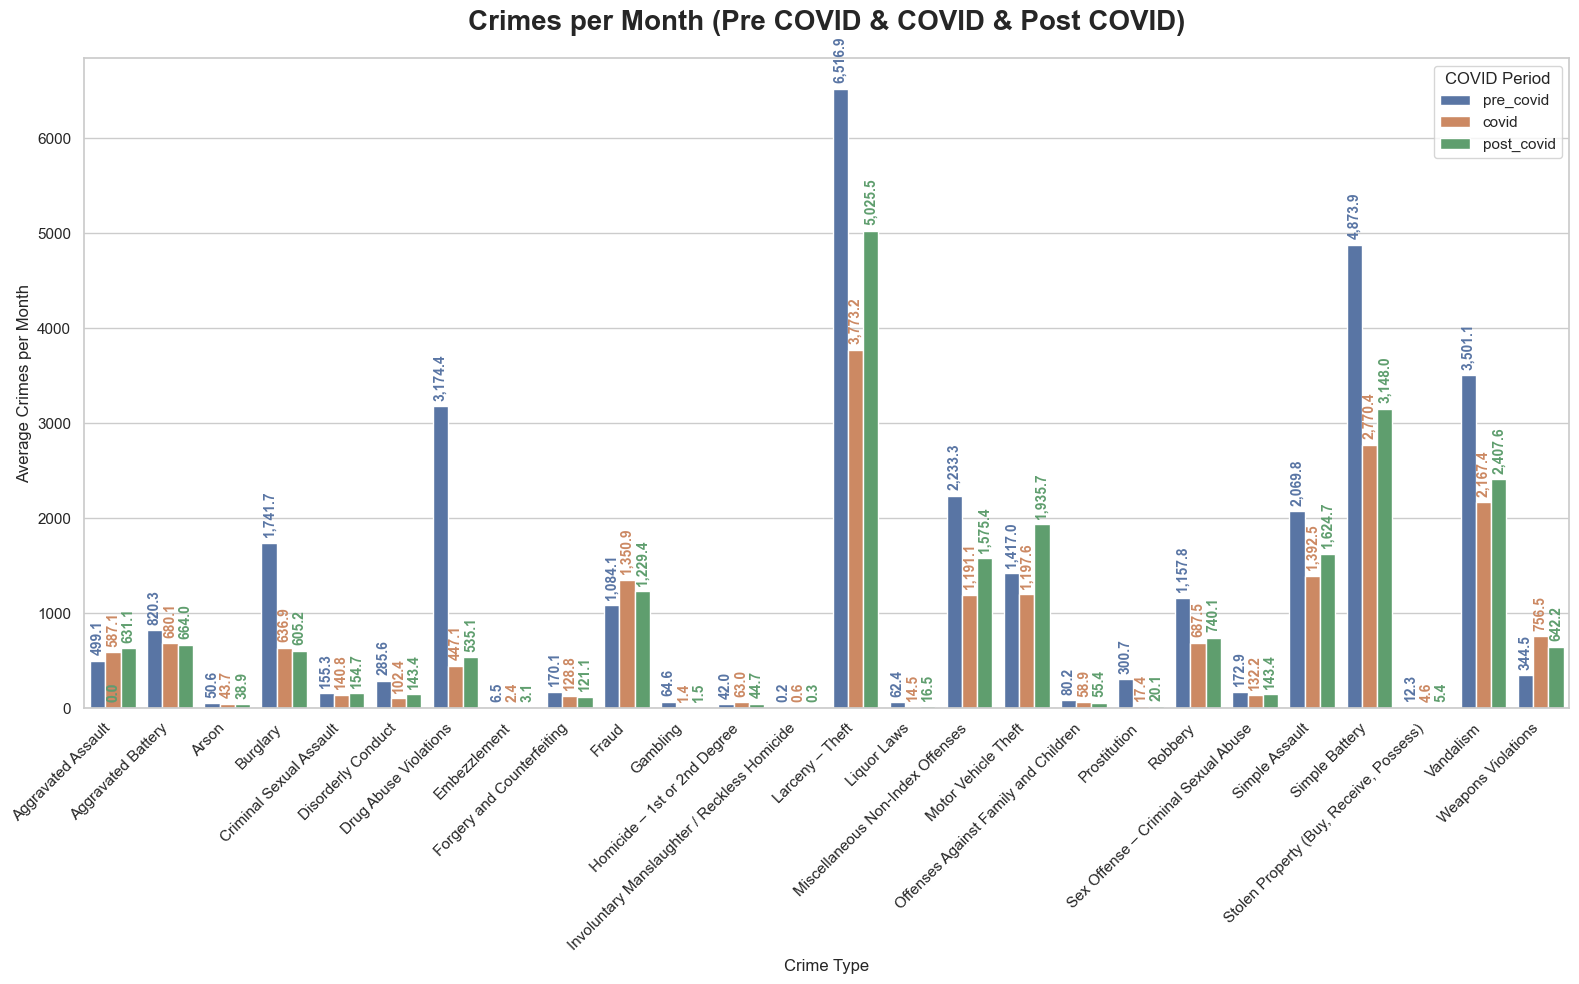

In [16]:
# Convert Arrow dictionary columns to plain Python strings 
df_plot = df_is_covid.reset_index()
df_plot["fbi_code_desc"] = df_plot["fbi_code_desc"].astype(str) 

# Enforce order
covid_order = ["pre_covid", "covid", "post_covid"]
df_plot["era"] = pd.Categorical(
    df_plot["era"],
    categories=covid_order,
    ordered=True
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))
ax = sns.barplot(
    data=df_plot,
    y="crimes_per_month",
    x="fbi_code_desc",
    hue="era"
)

for p in ax.patches:
    height = p.get_height()
    color = p.get_facecolor()   # get the bar's actual color

    ax.annotate(
        f"{height:,.1f}",                      # crimes per month, 1 decimal place
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),                        # fixed offset so labels never vanish
        textcoords="offset points",
        rotation=90,
        color=color,                          # use the bar color for the text
        fontweight='bold',
        clip_on=False                         # don't clip tiny bars
    )
 
plt.title(
    "Crimes per Month (Pre COVID & COVID & Post COVID)",
    pad=20,
    fontsize = 20,
    fontweight="bold"
)
plt.ylabel("Average Crimes per Month")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.legend(title="COVID Period")
plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/bar_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

#### Relative Percentage Change

#### $\text{Relative \% Change} = \left( \frac{V_{final} - V_{initial}}{V_{initial}} \right) \times 100$
- % change Pre‑COVID → COVID
- % change Pre‑COVID → Post‑COVID
- % change COVID → Post‑COVID

In [17]:
# Reshape to wide format (COVID vs non‑COVID side‑by‑side)
df_wide = (
    df_is_covid
    .reset_index()
    .astype({"fbi_code_desc": str, "era": str, "crime_count": float, "crimes_per_month": float}) # Convert to Pandas
    .pivot(index="fbi_code_desc", columns="era", values=["crime_count", "crimes_per_month"])
).reset_index()
# display
df_wide.head()

fbi_code_desc crime_count                       \
era                                covid post_covid pre_covid   
0         Aggravated Assault     19962.0    22088.0  114800.0   
1         Aggravated Battery     23125.0    23241.0  188665.0   
2                      Arson      1486.0     1360.0   11637.0   
3                   Burglary     21656.0    21181.0  400596.0   
4    Criminal Sexual Assault      4788.0     5415.0   35729.0   

    crimes_per_month                           
era            covid  post_covid    pre_covid  
0         587.117647  631.085714   499.130435  
1         680.147059  664.028571   820.282609  
2          43.705882   38.857143    50.595652  
3         636.941176  605.171429  1741.721739  
4         140.823529  154.714286   155.343478

In [18]:
# MultiIndex
crimes_per_month = 'crimes_per_month'
pct_change_impact = 'pct_change_impact'

# Add new columns
df_wide[(pct_change_impact,'pre_to_covid')] = (
    (df_wide[(crimes_per_month, 'covid')] - df_wide[(crimes_per_month, 'pre_covid')]) / df_wide[(crimes_per_month, 'pre_covid')] * 100
)
df_wide[(pct_change_impact, 'pre_to_post')] = (
    (df_wide[(crimes_per_month, 'post_covid')] - df_wide[(crimes_per_month, 'pre_covid')]) / df_wide[(crimes_per_month, 'pre_covid')] * 100
)
df_wide[(pct_change_impact, 'covid_to_post')] = (
    (df_wide[(crimes_per_month, 'post_covid')] - df_wide[(crimes_per_month, 'covid')]) / df_wide[(crimes_per_month, 'covid')] * 100    
)

# display
df_wide.head()

fbi_code_desc crime_count                       \
era                                covid post_covid pre_covid   
0         Aggravated Assault     19962.0    22088.0  114800.0   
1         Aggravated Battery     23125.0    23241.0  188665.0   
2                      Arson      1486.0     1360.0   11637.0   
3                   Burglary     21656.0    21181.0  400596.0   
4    Criminal Sexual Assault      4788.0     5415.0   35729.0   

    crimes_per_month                          pct_change_impact              \
era            covid  post_covid    pre_covid      pre_to_covid pre_to_post   
0         587.117647  631.085714   499.130435         17.628100   26.437033   
1         680.147059  664.028571   820.282609        -17.083813  -19.048805   
2          43.705882   38.857143    50.595652        -13.617316  -23.200629   
3         636.941176  605.171429  1741.721739        -63.430371  -65.254414   
4         140.823529  154.714286   155.343478         -9.346996   -0.405033   

                   
era covid_to_post  
0        7.488800  
1       -2.369853  
2      -11.094020  
3       -4.987862  
4        9.863946

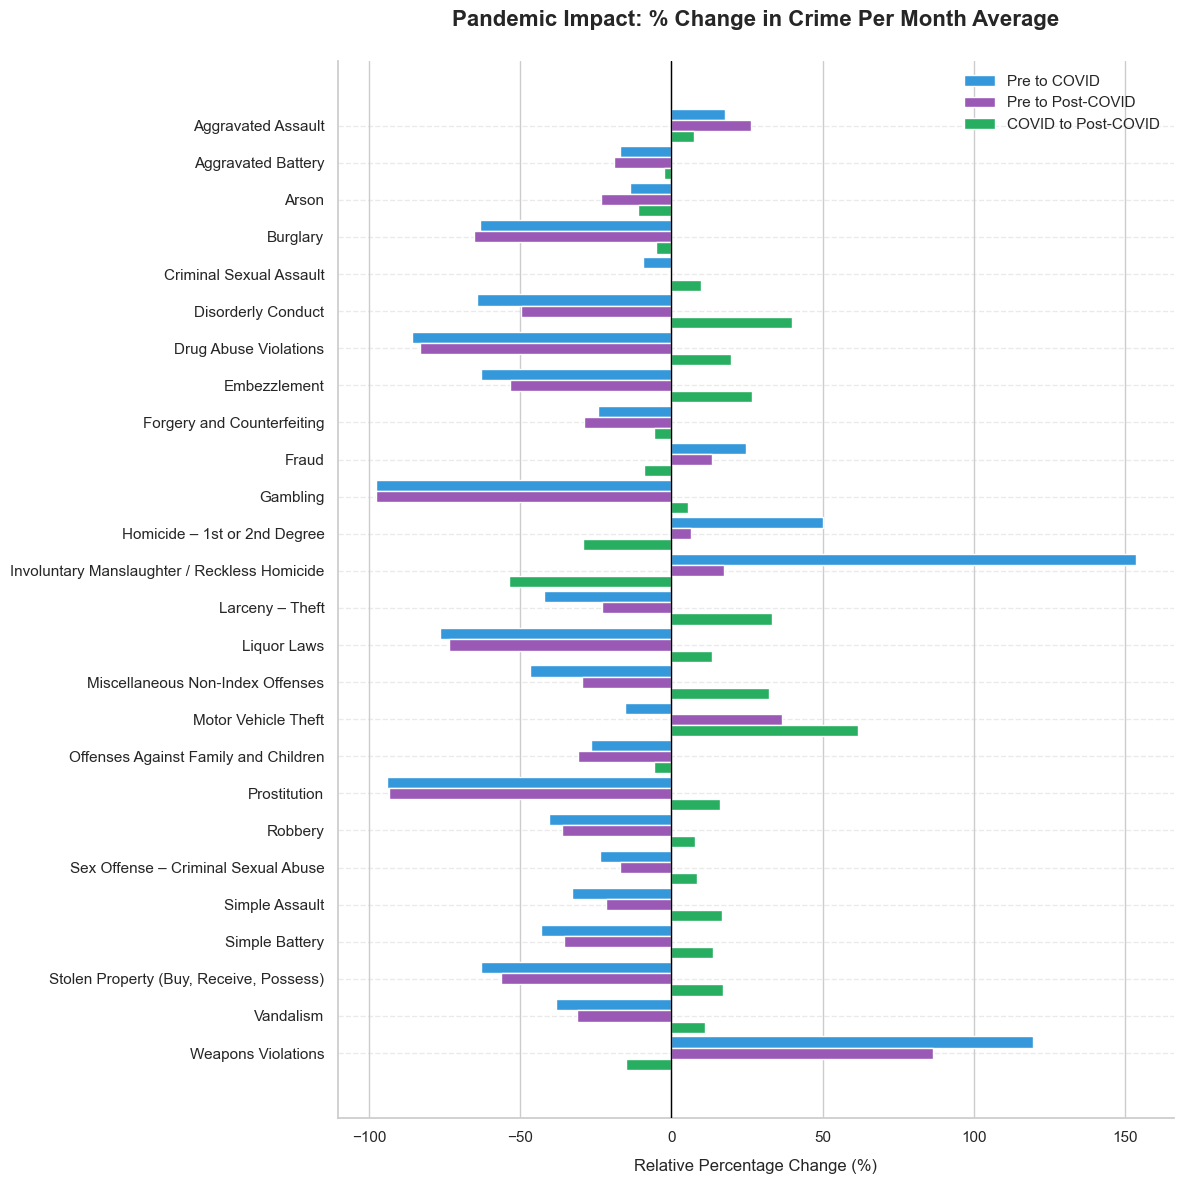

In [19]:
# Set ascending=False so that the first letter (A) appears at the top of the horizontal chart
df_wide = df_wide.sort_values(by='fbi_code_desc', ascending=False)
# plot variables
labels = df_wide['fbi_code_desc']
y = np.arange(len(labels))  # Label locations
height = 0.30  # Width of the bars

# Plot size
fig, ax = plt.subplots(figsize=(12, 12))

# Create grouped bars
ax.barh(y + height, df_wide[(pct_change_impact, 'pre_to_covid')], height, label='Pre to COVID', color='#3498db')
ax.barh(y, df_wide[(pct_change_impact, 'pre_to_post')], height, label='Pre to Post-COVID', color='#9b59b6')
ax.barh(y - height, df_wide[(pct_change_impact, 'covid_to_post')], height, label='COVID to Post-COVID', color='#27ae60')

# Aesthetics
# No bar labels intentional — chart shows direction of change (increase/decrease)
# not exact values. Zero baseline communicates the story.
ax.axvline(0, color='black', linewidth=1.0, zorder=3)
ax.set_title('Pandemic Impact: % Change in Crime Per Month Average', fontsize=16, pad=25, fontweight='bold')
ax.set_xlabel('Relative Percentage Change (%)', fontsize=12, labelpad=10)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.legend(frameon=False, loc='upper right')

# Add grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Remove chart junk
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/impact_of_covid.png", dpi=1200, bbox_inches='tight')
plt.show()

In [20]:
df_wide.sort_values('fbi_code_desc')

fbi_code_desc crime_count             \
era                                                     covid post_covid   
0                              Aggravated Assault     19962.0    22088.0   
1                              Aggravated Battery     23125.0    23241.0   
2                                           Arson      1486.0     1360.0   
3                                        Burglary     21656.0    21181.0   
4                         Criminal Sexual Assault      4788.0     5415.0   
5                              Disorderly Conduct      3481.0     5018.0   
6                           Drug Abuse Violations     15202.0    18728.0   
7                                    Embezzlement        82.0      107.0   
8                      Forgery and Counterfeiting      4378.0     4240.0   
9                                           Fraud     45931.0    43028.0   
10                                       Gambling        47.0       51.0   
11                   Homicide – 1st or 2nd Degree      2143.0     1564.0   
12   Involuntary Manslaughter / Reckless Homicide        21.0       10.0   
13                                Larceny – Theft    128289.0   175894.0   
14                                    Liquor Laws       494.0      576.0   
15               Miscellaneous Non-Index Offenses     40498.0    55138.0   
16                            Motor Vehicle Theft     40717.0    67749.0   
17           Offenses Against Family and Children      2001.0     1940.0   
18                                   Prostitution       590.0      704.0   
19                                        Robbery     23376.0    25903.0   
20            Sex Offense – Criminal Sexual Abuse      4495.0     5018.0   
21                                 Simple Assault     47344.0    56863.0   
22                                 Simple Battery     94194.0   110180.0   
23        Stolen Property (Buy, Receive, Possess)       156.0      188.0   
24                                      Vandalism     73693.0    84265.0   
25                             Weapons Violations     25722.0    22476.0   

               crimes_per_month                           pct_change_impact  \
era  pre_covid            covid   post_covid    pre_covid      pre_to_covid   
0     114800.0       587.117647   631.085714   499.130435         17.628100   
1     188665.0       680.147059   664.028571   820.282609        -17.083813   
2      11637.0        43.705882    38.857143    50.595652        -13.617316   
3     400596.0       636.941176   605.171429  1741.721739        -63.430371   
4      35729.0       140.823529   154.714286   155.343478         -9.346996   
5      65699.0       102.382353   143.371429   285.647826        -64.157839   
6     730123.0       447.117647   535.085714  3174.447826        -85.915105   
7       1505.0         2.411765     3.057143     6.543478        -63.142466   
8      39122.0       128.764706   121.142857   170.095652        -24.298649   
9     249345.0      1350.911765  1229.371429  1084.108696         24.610362   
10     14862.0         1.382353     1.457143    64.617391        -97.860711   
11      9657.0        63.029412    44.685714    41.986957         50.116648   
12        56.0         0.617647     0.285714     0.243478        153.676471   
13   1498883.0      3773.205882  5025.542857  6516.882609        -42.101061   
14     14352.0        14.529412    16.457143    62.400000        -76.715686   
15    513650.0      1191.117647  1575.371429  2233.260870        -46.664643   
16    325900.0      1197.558824  1935.685714  1416.956522        -15.483728   
17     18446.0        58.852941    55.428571    80.200000        -26.617280   
18     69160.0        17.352941    20.114286   300.695652        -94.229068   
19    266303.0       687.529412   740.085714  1157.839130        -40.619608   
20     39763.0       132.205882   143.371429   172.882609        -23.528524   
21    476065.0      1392.470588  1624.657143  2069.847826        -32.725944   
22   112100

#### Summary
The analysis of crime patterns across pre-COVID, COVID, and post-COVID periods reveals a clear structural shift in offense trends rather than a simple return to baseline. During the COVID period, many property and socially visible crimes, such as burglary, robbery, drug violations, and prostitution, declined sharply, reflecting reduced mobility and public activity. The most pronounced change is observed in Drug Abuse Violations, which declined by 83.1% from pre-COVID to post-COVID, indicating a sustained structural reduction rather than a temporary pandemic effect. In contrast, several property crimes rebounded strongly after COVID, particularly motor vehicle theft, which increased by 36.6% from pre-COVID to post-COVID, with the steepest acceleration occurring between the COVID and post-COVID periods (+61.6%), signaling a post-pandemic resurgence in auto-related theft. Violent crime trends were mixed: aggravated assault increased and remained elevated, while homicide declined during COVID but stabilized afterward. Notably, weapons violations spiked sharply during COVID (+119.6%) and partially retreated post-COVID, but remained significantly elevated at +86.4% above pre-COVID levels, indicating a persistent structural shift in weapon-related offenses. However, pre-existing trends in some categories, such as the steady rise in aggravated assault, suggest that not all observed changes can be attributed solely to COVID disruption. Overall, the findings suggest COVID acted as a disruption point that suppressed certain crime categories while permanently reshaping others, resulting in a redistributed post-pandemic crime landscape rather than a uniform reversion to pre-COVID conditions.

In [21]:
# Group by the level name and sum up the sizes
week_counts = (
    multi_counts.groupby(level=['fbi_code_desc', 'Indexed', 'year_week', 'era'])
    .sum()
    .reset_index(name='count')
    .astype({'count': 'int64[pyarrow]'})
             )
# display
print(week_counts.isna().any())
week_counts.sort_values(['fbi_code_desc', 'year_week'])
week_counts.head()

fbi_code_desc    False
Indexed          False
year_week        False
era              False
count            False
dtype: bool


,fbi_code_desc,Indexed,year_week,era,count
0,Aggravated Assault,I,2001-01,pre_covid,133
1,Aggravated Assault,I,2001-02,pre_covid,128
2,Aggravated Assault,I,2001-03,pre_covid,112
3,Aggravated Assault,I,2001-04,pre_covid,119
4,Aggravated Assault,I,2001-05,pre_covid,127


In [22]:
# Distinct Crime Type Values
print(list(multi_counts.index.get_level_values('fbi_code_desc').unique()))

['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault', 'Disorderly Conduct', 'Drug Abuse Violations', 'Embezzlement', 'Forgery and Counterfeiting', 'Fraud', 'Gambling', 'Homicide – 1st or 2nd Degree', 'Involuntary Manslaughter / Reckless Homicide', 'Larceny – Theft', 'Liquor Laws', 'Miscellaneous Non-Index Offenses', 'Motor Vehicle Theft', 'Offenses Against Family and Children', 'Prostitution', 'Robbery', 'Sex Offense – Criminal Sexual Abuse', 'Simple Assault', 'Simple Battery', 'Stolen Property (Buy, Receive, Possess)', 'Vandalism', 'Weapons Violations']


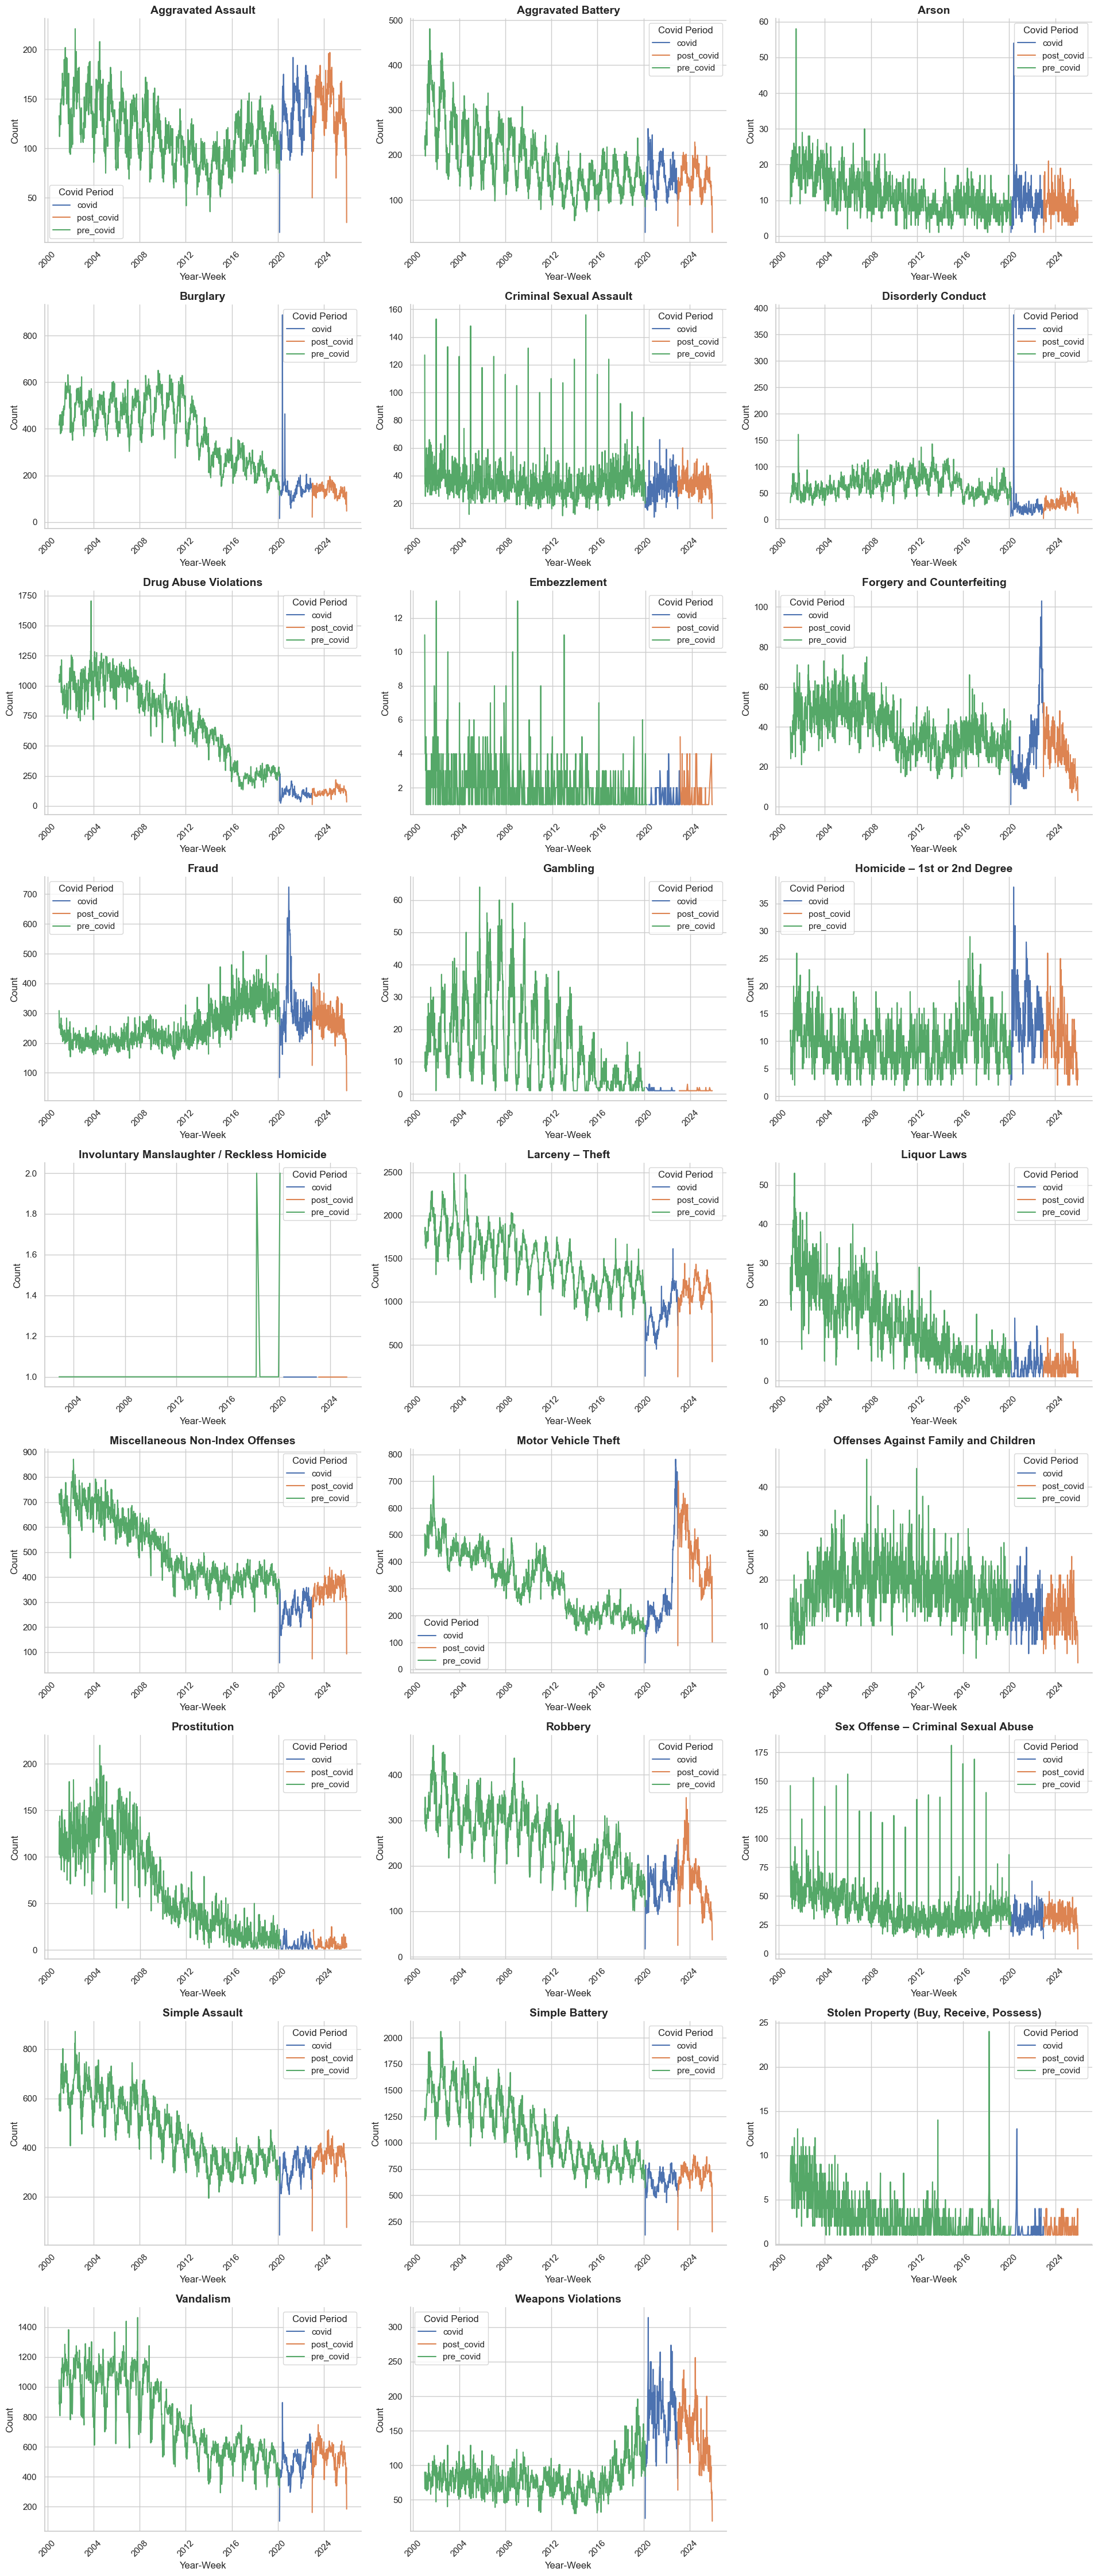

In [23]:
# Convert to Plot-friendly format
convert = week_counts.assign(
    year_week=lambda d: pd.to_datetime(d["year_week"] + "-1", format="%G-%V-%u"),
    count=lambda d: d["count"].astype("float64"),
    era=lambda d: d["era"].astype("category"),
    fbi_code_desc=lambda d: d["fbi_code_desc"].astype("string")
)
# create a FacetGrid of line plots object
g = sns.relplot(
    data=convert,
    x="year_week",
    y="count",
    hue="era",
    col="fbi_code_desc",
    col_wrap=3,
    kind="line",
    height=5,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': False},
    legend=True # Keep this True initially so labels are generated
)

# Extract labels and handles from the global legend before removing
handles, labels = g._legend.legend_handles, [t.get_text() for t in g._legend.get_texts()]

# Remove the default global legend
g._legend.remove()

# Fix titles
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# Iterate through axes to format and add the legend manually
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)   
    # Manually pass the handles and labels we extracted
    ax.legend(handles=handles, labels=labels, title="Covid Period")
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Count")

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/time_line_crime_plot.png", bbox_inches='tight')
plt.show()

In [24]:
convert.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31537 entries, 0 to 31536
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype                                                       
---  ------         --------------  -----                                                       
 0   fbi_code_desc  31537 non-null  string                                                      
 1   Indexed        31537 non-null  dictionary<values=string, indices=int32, ordered=0>[pyarrow]
 2   year_week      31537 non-null  datetime64[ns]                                              
 3   era            31537 non-null  category                                                    
 4   count          31537 non-null  float64                                                     
dtypes: category(1), datetime64[ns](1), dictionary<values=string, indices=int32, ordered=0>[pyarrow](1), float64(1), string(1)
memory usage: 893.4 KB


## Indexed Plot

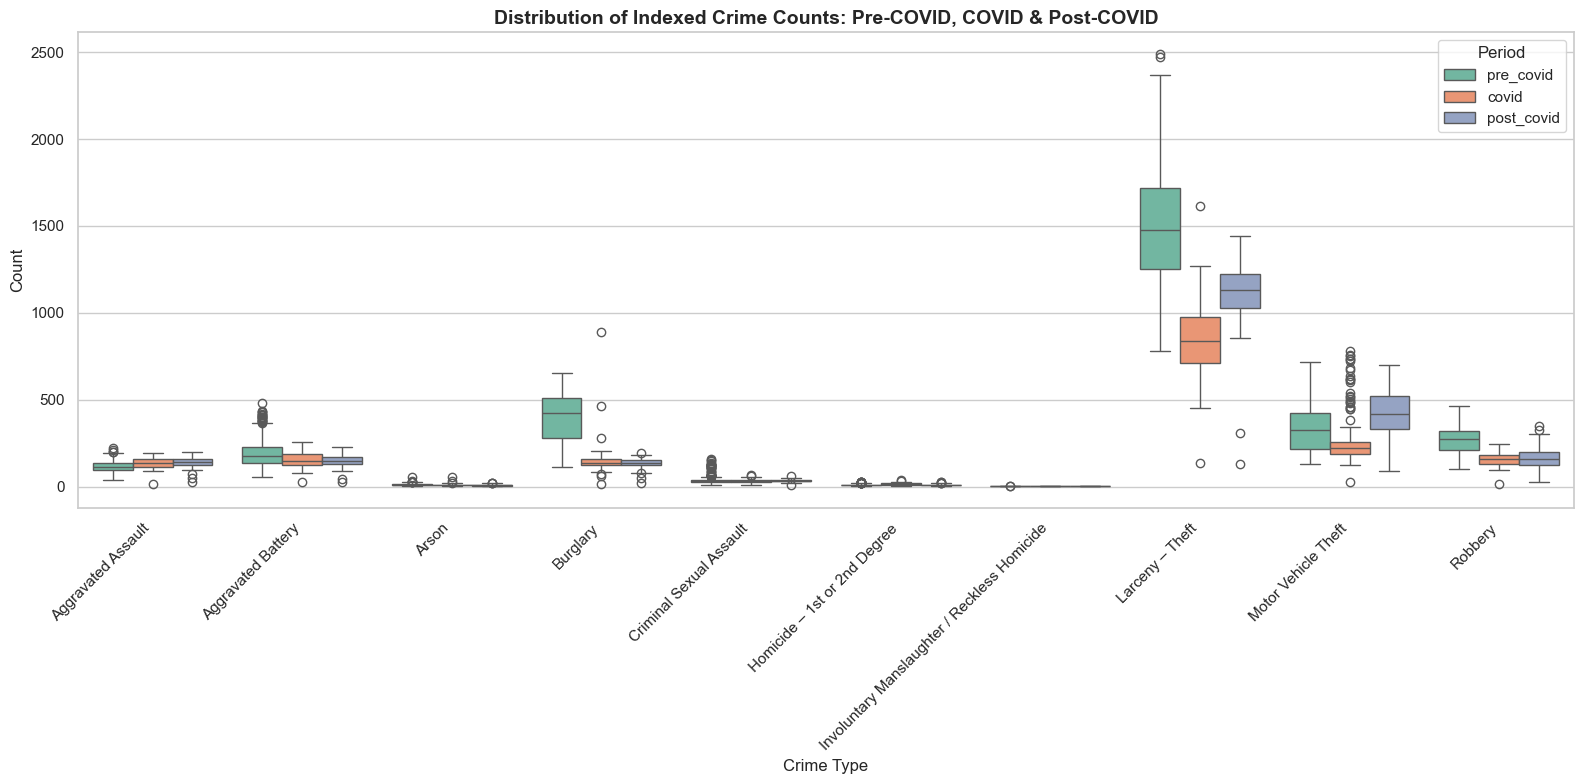

In [25]:
# Note: pre-COVID has ~998 weeks vs ~143 (COVID) and ~125 (post-COVID)
# Median and IQR are comparable across eras — more pre-COVID outlier
# dots expected due to larger sample size, not higher crime volatility
# Define your desired order
legend_order = ["pre_covid", "covid", "post_covid"]
legend_title = "Period"

# plot size
plt.figure(figsize=(16, 8))

# Add 'hue_order' to the boxplot call
ax = sns.boxplot(
    data=convert.loc[convert.Indexed == 'I'],
    x="fbi_code_desc",
    y="count",
    hue="era",
    hue_order=legend_order,  # Ensures boxes follow the specific order
    palette="Set2"
)
# labels
plt.xticks(rotation=45, ha='right')
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.title("Distribution of Indexed Crime Counts: Pre-COVID, COVID & Post-COVID", size=14, weight='bold')

# legend handling
ax.legend(title=legend_title, frameon=True)

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/box_indexed_crime_plot.png", bbox_inches='tight')
plt.show()

## Non-Indexed

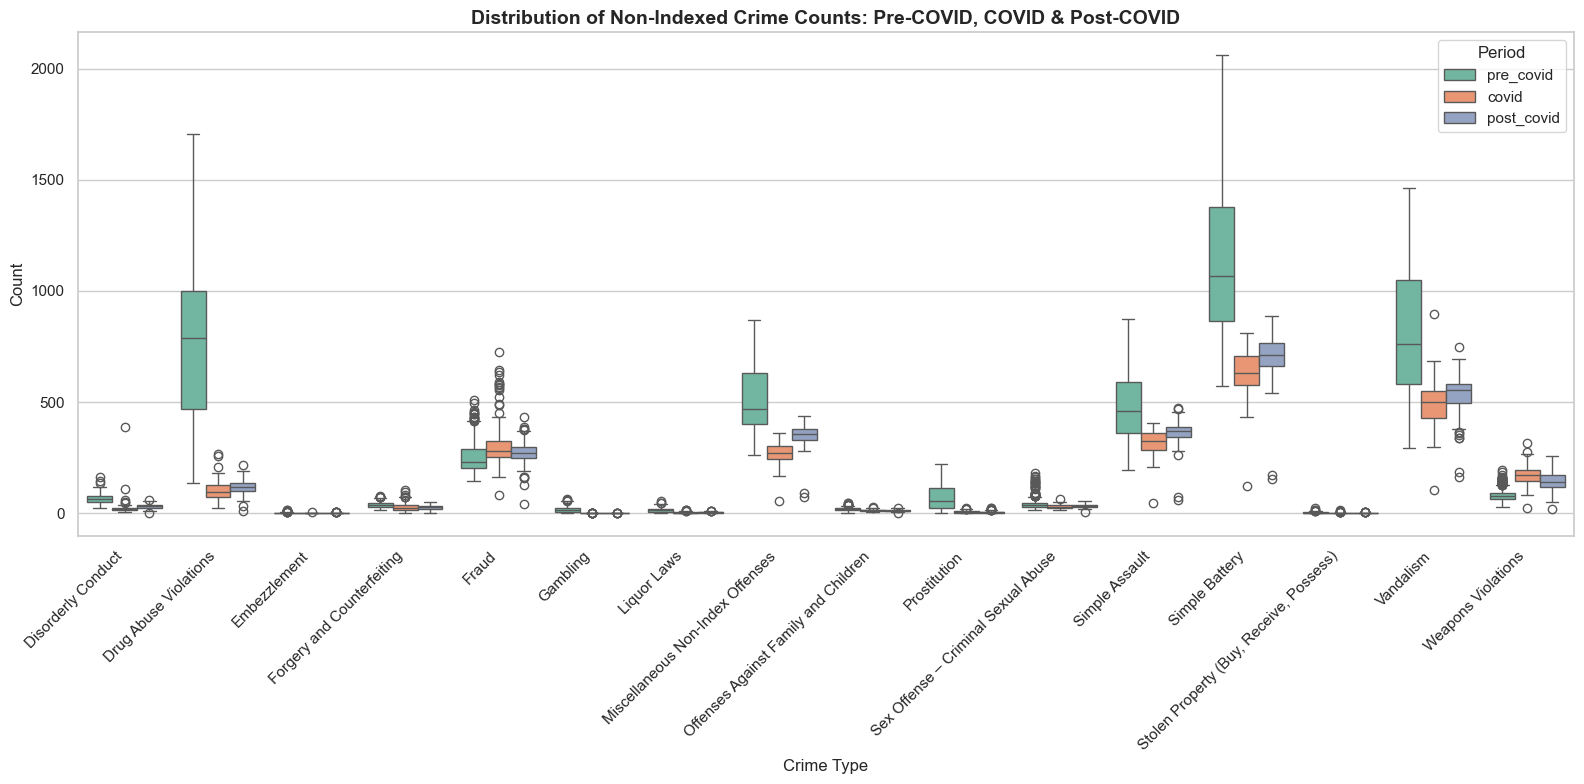

In [26]:
# Define your desired order
legend_order = ["pre_covid", "covid", "post_covid"]
legend_title = "Period"

# plot size
plt.figure(figsize=(16, 8))

# Add 'hue_order' to the boxplot call
ax = sns.boxplot(
    data=convert.loc[convert.Indexed == 'N'],
    x="fbi_code_desc",
    y="count",
    hue="era",
    hue_order=legend_order,  # Ensures boxes follow the specific order
    palette="Set2"
)
# labels
plt.xticks(rotation=45, ha='right')
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.title("Distribution of Non-Indexed Crime Counts: Pre-COVID, COVID & Post-COVID", size=14, weight='bold')

# legend handling
ax.legend(title=legend_title, frameon=True)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/box_nonindexed_crime_plot.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

## Save using PyArrow

In [27]:
# Save as Arrow
df.to_feather("../Data/crime_data_covid.feather")